<img align='center' style='max-width: 1000px' src='assets/banner.png'>

<img align='right' style='max-width: 200px; height: auto' src='assets/hsg_logo.png'>

#  Lab 09 - Recurrent Neural Networks

Artificial Intelligence (Spring 2026), University of St. Gallen

## Part 1: RNN Text Generation

In this notebook, we will explore the power of recurrent neural networks (RNNs) for generating text. Specifically, we will train a character-level RNN using PyTorch on the Shakespeare's Sonnet dataset. We will implement the RNN from scratch (without using the RNN module from `torch.nn`) and train it in batches to handle variable-length sequences. After training, we will evaluate the model by generating random prompts. Then we will implement an LSTM-based model using the LSTM module from PyTorch to see how it can improve the quality of the output. Below you can see the illustration of the models we aim to implement:

<img align='center' style='max-width: 600px' src='assets/animations/objective.gif'>

Lab Objectives:
- Learn how to create a PyTorch dataset for sequence-based training of textual data.
- Implement an RNN from scratch using PyTorch that predicts the next character given a context.
- Generate random texts by prompting the model.
- Improve upon the RNN model and implement an LSTM-based model. 


We will see how the model can generate text that resembles Shakespeare's sonnets.


### 1. Dataset 

The dataset we will be using for this notebook is the collection of 154 sonnets by William Shakespeare. The sonnets were published in 1609 and have since become some of the most famous and influential poems in English literature.

You can download the dataset from the Project Gutenberg website, which is a repository of free ebooks that are in the public domain. The sonnets are available for free download and can be used for any purpose without restriction. However, it's worth noting that some adaptations of the sonnets or translations may be protected by copyright, so it's always important to double-check the legal status of any text you plan to use for your project.

For more information, please refer to this link: https://www.gutenberg.org/ebooks/1041


The preprocessed version of the dataset can be downloaded from the link below:

Download link: https://raw.githubusercontent.com/ccc-frankfurt/Practical_ML_SS21/master/week06/sonnets.txt

Before everything, let's import some libraries that we will use for data processing, training and evaluation:

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

#### Loading the dataset in PyTorch

The first step is to understand how the data looks and how to prepare it for training. Since we cannot directly work with characters in neural networks, we need to map each character in the dataset to a unique identifier:

<img align='center' style='max-width: 800px' src='assets/animations/char_mapping.gif'>

Since we want to train the model to predict the next character based on the seen context, the inputs and outputs for model training are constructed by randomly selecting sub-strings from the dataset to construct each pair. The input to the model will be the substring itself and the target will be the substring shifted to the left by one character: 

<img align='center' style='max-width: 800px' src='assets/batch_example.png'>

To create a PyTorch dataset for our data, we need to define a class that inherits from the class `Dataset` in `torch.utils.data`. In the constructor of the class, we load the text data and prepare the mappings.

In [2]:
class SonnetDataset(Dataset):
    def __init__(self, ds_path, seq_length):
        # Read text file
        with open(ds_path, 'r') as f:
            text = f.read()

        # Create set of all possible unique characters. Additionally add the character `#`
        # as an indicator of the end of the sentence. 
        self.chars = ['#'] + sorted(list(set(text)))

        # Char-to-ID and ID-to-Char mappers
        char_to_int = {c: i for i, c in enumerate(self.chars)}
        int_to_char = {i: c for i, c in enumerate(self.chars)}

        self.text = text
        self.char_to_int = char_to_int
        self.int_to_char = int_to_char
        
        # Number of characters per input sequence (context window length)
        self.seq_length = seq_length  
 
    def __len__(self):
        # Return the total number of sequences in the dataset
        return len(self.text) - self.seq_length + 1
        
    def __getitem__(self, index):
        # Return a substring and its corresponding target.
        sequence = self.text[index:index + self.seq_length]
        target = self.text[index + 1:index + self.seq_length] + '#'
        
        return torch.tensor([self.char_to_int[c] for c in sequence], dtype=torch.long), torch.tensor([self.char_to_int[c] for c in target], dtype=torch.long)

Input:
- text = ABCDEFG
- seq_length = 3
- index = 0

Output:
- sequence = ABC
- target =   BC#


Notice: Here we don't convert to ids.

Now, we create an instance of the dataset which will be used for training both models.

In [3]:
# sonnets.txt is stored locally in this directory

In [4]:
dataset = SonnetDataset(ds_path="./sonnets.txt", seq_length=100)
dataset[0]

(tensor([18, 53, 50, 48,  2, 41, 36, 44, 53, 40, 54, 55,  2, 38, 53, 40, 36, 55,
         56, 53, 40, 54,  2, 58, 40,  2, 39, 40, 54, 44, 53, 40,  2, 44, 49, 38,
         53, 40, 36, 54, 40,  7,  1, 31, 43, 36, 55,  2, 55, 43, 40, 53, 40, 37,
         60,  2, 37, 40, 36, 56, 55, 60,  4, 54,  2, 53, 50, 54, 40,  2, 48, 44,
         42, 43, 55,  2, 49, 40, 57, 40, 53,  2, 39, 44, 40,  7,  1, 14, 56, 55,
          2, 36, 54,  2, 55, 43, 40,  2, 53, 44]),
 tensor([53, 50, 48,  2, 41, 36, 44, 53, 40, 54, 55,  2, 38, 53, 40, 36, 55, 56,
         53, 40, 54,  2, 58, 40,  2, 39, 40, 54, 44, 53, 40,  2, 44, 49, 38, 53,
         40, 36, 54, 40,  7,  1, 31, 43, 36, 55,  2, 55, 43, 40, 53, 40, 37, 60,
          2, 37, 40, 36, 56, 55, 60,  4, 54,  2, 53, 50, 54, 40,  2, 48, 44, 42,
         43, 55,  2, 49, 40, 57, 40, 53,  2, 39, 44, 40,  7,  1, 14, 56, 55,  2,
         36, 54,  2, 55, 43, 40,  2, 53, 44,  0]))

### 2. Vanilla RNNs

<img align='center' style='max-width: 800px' src='assets/animations/rnn_generation.gif'>

#### 2.1 RNN Cell

The core component of an RNN model is an RNN cell that requires two inputs. One input is the current character in the text and the other input is the hidden state of the model. The hidden state is also known as the memory of the model that carries useful information along the text which enables prediction based on a given context. In the figure below, we can see that some mathematical operation is performed on the inputs to make a prediction for the output at step t and update the hidden vector based on the current input:

<img align='center' style='max-width: 400px' src='assets/rnn_cell.png'>

Let's first define the RNN cell:

In [5]:
# Define the RNN Cell
class RNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(RNNCell, self).__init__()
        # Linear transformation for the input
        self.input_hidden = nn.Linear(input_size, hidden_size)
        # Linear transformation for the hidden state
        self.hidden_hidden = nn.Linear(hidden_size, hidden_size)
        # Activation and dropout
        self.activation = nn.Tanh()
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x, hidden):
        # Transform input
        x = self.input_hidden(x)
        # Transform hidden state
        hidden_t = self.hidden_hidden(hidden)
        # Add the transformed hidden state to the transformed input to
        # form the new hidden state
        new_hidden = self.activation(x + hidden_t)
        new_hidden = self.dropout(new_hidden)
      
        return new_hidden

In [6]:
rnn_cell = RNNCell(128, 128)

x = torch.randn(5, 128)
h = torch.randn(5, 128)

rnn_cell(x, h).shape

torch.Size([5, 128])

To ensure reproducibility, we seed all random number generators before building the model. This guarantees that the weight initialization and any stochastic operations produce the same results across runs.

In [7]:
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

#### 2.2 RNN Model

One last point for the implementation of the RNN model is the conversion of text character IDs to vectors. Two common options for converting integers to vectors are followed in practice.

1 - One-hot encoded vectors

2 - Using embedding look-up tables

For this tutorial, we go for the second option. To do so we use the `nn.Embedding` module from PyTorch that initializes a list of trainable tensors, one per character in our case. Every time we give it a list of character IDs, it selects the corresponding tensors from the table and returns them. We then use those tensors as inputs to the RNN cell.

In [8]:
# Define the RNN model
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        # Character embedding
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=hidden_size)
        # RNN cell
        self.rnn_cell = RNNCell(hidden_size, hidden_size)
        # Classification layer
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden):
        # Convert input to vector embeddings using a lookup table
        x_emb = self.embedding(x)
        # Forward the input and hidden state to the RNN cell
        new_hidden = self.rnn_cell(x_emb, hidden)
        # Make prediction using the new hidden state
        output = self.fc(new_hidden)
        
        return output, new_hidden
    
    def init_hidden(self, batch_size):
        return torch.zeros(batch_size, self.hidden_size)


The `nn.Embedding` module acts as a lookup table of shape `(vocab_size, embedding_dim)`, where each row is a trainable vector representing one character. When you pass a character ID (e.g. `36`), it simply returns the corresponding row — no matrix multiplication needed. This is equivalent to multiplying a one-hot vector by a weight matrix, but far more efficient since it skips the multiply and does a direct row fetch instead. The row vectors are initialized randomly and updated through backpropagation, so over training, characters that appear in similar contexts naturally end up with similar vectors.

In [9]:
model = SimpleRNN(vocab_size=len(dataset.chars), hidden_size=128)

#### 2.3 Text Generation

Before training the model, we want to test it with text generation to check how the generated texts look. We need to implement a function that takes as input the model, the character <-> char-ID converters and the prompt.

In [10]:
# Generate random text
def generate_text(model, char_to_int, int_to_char, prompt, device):
    # Set model to eval mode
    model.eval()

    # Initialize the hidden state of the RNN cell with batch-size = 1
    hidden = model.init_hidden(1)
    if type(hidden) == tuple:
        hidden = (hidden[0].squeeze(1).to(device), hidden[1].squeeze(0).to(device))
    else:
        hidden = hidden.to(device)
    
    # Convert the prompt characters to character IDs
    input_sequence = torch.tensor([char_to_int[c] for c in prompt], dtype=torch.long).unsqueeze(0).to(device)
    
    # Store the generated text over time as a string
    generated_text = prompt

    # No gradient mode during inference
    with torch.no_grad():
        # First feed all prompt characters to the model to get the final output and hidden state
        for i in range(len(input_sequence[0])):
            output, hidden = model(input_sequence[0][i].unsqueeze(0), hidden)

        next_input = torch.argmax(output, dim=1)

        # Generate text until the model outputs character #
        while True:
            # At each step, predict the next character given the current input and 
            # the hidden state from previous step
            output, hidden = model(next_input, hidden)
            # Sample from the probability distribution produced by the model at step t
            probabilities = nn.functional.softmax(output, dim=1)

            # predicted_char = torch.argmax(probabilities, dim=1)

            # Instead of always picking the most probable character (greedy), torch.multinomial samples from the probability
            # distribution — characters with higher probability are more likely to be picked, but lower-probability characters
            # can still be chosen occasionally. This introduces randomness into the generated text, which produces more varied and natural-looking output.
            predicted_char = torch.multinomial(probabilities[0], 1)

            
            # Convert the character ID to string and add it to `generated_text`
            if int_to_char[predicted_char[0].item()] == "#": 
                break
            generated_text += int_to_char[predicted_char[0].item()]
            next_input = predicted_char

    return generated_text

In [11]:
prompt = "St. Gallen, where the "
generate_text(model, dataset.char_to_int, dataset.int_to_char, prompt, device=torch.device("cpu"))

"St. Gallen, where the V?A\n,\nrY!AUPSIcmTsP\nJmOxyaI?CFKVKhSIFB'cNVT)B(sVPr:Y'NU:;sqr,"

#### 2.4 Training

We saw that the randomly initialized model generates meaningless random text. Let's train the model on the Shakespeare's sonnets dataset. Since we need to train the model on a sequence of inputs, the computational graph of the model needs to be replicated over all steps of the character sequence generation process. At the end of the sentence, the losses from all steps are summed together and backpropagation is applied to compute the gradients. In this case we are doing `Backpropagation Through Time` (BPTT). In the animation below, we can see how the forward and backward propagation is performed for sequential data generation:

<img align='center' style='max-width: 900px' src='assets/animations/rnn_training.gif'>

Similar to before, we need to define a function that trains the model for a number of epochs. The only part that is different is how we feed the data to the model. One way to input sequential data is to iterate through the batch sequences step by step, forward the characters at step t and compute the loss for that step. After going through the sequence, we compute the average loss and backpropagate. PyTorch takes care of the BPTT part :)

In [12]:
def train(model, dataloader, criterion, optimizer, device):
    model.train()
    dataloader_progress = tqdm.tqdm(dataloader)
    iter_losses = []
    # Iterate over all dataset sentences
    for i, (inputs, targets) in enumerate(dataloader_progress):
        # Size of input and targets: B x L
        # B -> batch size, L -> sequence length
        inputs, targets = inputs.to(device), targets.to(device)
        batch_size = inputs.shape[0]
        len_sequence = inputs.shape[1]
        # Initialize the hidden state with zeros before going through the sequence
        hidden = model.init_hidden(batch_size).to(device)
        optimizer.zero_grad()
        loss = 0
        # Make prediction for each character and compute the loss for each step
        for t in range(len_sequence):
            output, hidden = model(inputs[:, t], hidden)
            loss += criterion(output, targets[:, t])
        # Compute average loss over all steps
        loss = loss / len_sequence
        # Backpropagate and optimizer step
        loss.backward()
        optimizer.step()
        dataloader_progress.set_description(f"Loss: {loss.item():0.5f}")
        # Iteration loss
        iter_losses.append(loss.item())

    return np.mean(iter_losses)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# Hyperparameters
hidden_size = 256
seq_length = 100
batch_size = 64 
num_epochs = 3
learning_rate = 0.001

model = SimpleRNN(vocab_size=len(dataset.chars), hidden_size=hidden_size)
model.to(device)
model.train()

# Create dataset and dataloader
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Train the model
epoch_losses = []
for epoch in range(num_epochs):
    epoch_loss = train(model, dataloader, criterion, optimizer, device)
    print(f'Epoch {epoch + 1}/{num_epochs} completed')
    epoch_losses.append(epoch_loss)

Loss: 1.90044: 100%|██████████| 1468/1468 [01:02<00:00, 23.55it/s]


Epoch 1/3 completed


Loss: 1.91290: 100%|██████████| 1468/1468 [01:03<00:00, 23.08it/s]


Epoch 2/3 completed


Loss: 1.93843: 100%|██████████| 1468/1468 [01:03<00:00, 22.97it/s]

Epoch 3/3 completed


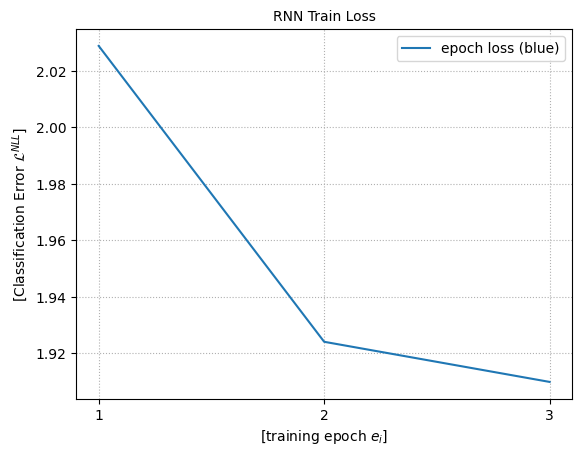

In [14]:
# Prepare plot
fig = plt.figure()
ax = fig.add_subplot(111)

# Add grid
ax.grid(linestyle='dotted')

# Plot the training epochs vs. the epochs' classification error
ax.plot(np.array(range(1, len(epoch_losses)+1)), epoch_losses, label='epoch loss (blue)')

# Plot details
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_xlabel("[training epoch $e_i$]", fontsize=10)
ax.set_ylabel(r"[Classification Error $\mathcal{L}^{NLL}$]", fontsize=10)
plt.legend(loc="upper right", numpoints=1, fancybox=True)
plt.title('RNN Train Loss', fontsize=10);

#### 2.5 Testing

Finally, it's time for testing the model. 

In [15]:
prompt = "St. Gallen, where the "
model.to("cpu")
generate_text(model, dataset.char_to_int, dataset.int_to_char, prompt, device=torch.device("cpu"))

'St. Gallen, where the orth hast in and am thy write wine,\nNor give,\nStade:\nWhint,\nSimpa'

### 3. LSTMs

We saw that RNNs can suffer from the vanishing gradient problem, which means that the gradients used to update the parameters of the network can become very small over time, leading to slow convergence and poor performance. Now let's see how we can solve that issue.


#### 3.1 LSTM Cell


LSTMs are designed to overcome the vanishing gradient problem by using a more sophisticated architecture that incorporates a memory cell and multiple gating mechanisms. The memory cell is responsible for storing information over long periods of time, while the gating mechanisms control the flow of information into and out of the cell. This allows LSTMs to selectively forget or remember information, which makes them more effective in capturing long-term dependencies in sequential data. Below you can see the architecture of an LSTM cell:

<img align='center' style='max-width: 700px' src='assets/lstmcell.png'>

Gates:
- **Forget gate** $f_t$: How much of what I knew before is still relevant?
- **Candidate** $c'_t$: Given the current input and context, what new information could I write to memory?
- **Input gate** $i_t$: How much of this candidate should I actually write to memory?
- **Output gate** $o_t$: How much of my current memory should I expose as output?

All the gates are first computed in parallel before the cell and hidden states get updated.

States:
| | Cell state **cₜ** | Hidden state **hₜ** |
|--|--|--|
| Role | Long-term memory | Short-term memory / output |
| Range | Unbounded (accumulates via addition) | (-1, 1) via tanh |
| Passed to | Next time step only | Next time step + prediction head |
| Modified by | Forget & input gates | Output gate + tanh(cₜ) |


Everything remains similar to the RNN implementation, but here we want to use PyTorch's LSTM module from `nn.LSTM` instead of implementing it from scratch. Let's first create an instance of an LSTM cell and see how we can interact with it.

In [16]:
# Create an instance of nn.LSTM. It's important to set batch_first=True if the data tensor shape is B x L x D
lstm = nn.LSTM(10, 30, batch_first=True)
# Initialize input, and the first hidden and context vectors
inp = torch.randn(5, 3, 10)
h0 = torch.randn(1, 5, 30)
c0 = torch.randn(1, 5, 30)
# Forward
output, (hn, cn) = lstm(inp, (h0, c0))

#### 3.2 LSTM Model

Now, let's implement the LSTM model. We use an `nn.Embedding` module to convert character IDs to learnable tensors.

In [17]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, hidden_size, dropout=0.5):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        # Character embedding module
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        # PyTorch's LSTM module
        self.lstm = nn.LSTM(hidden_size, hidden_size, dropout=dropout, batch_first=True)
        # Classification layer
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden):
        x = self.embedding(x)
        output, hidden = self.lstm(x, hidden)
        output = self.fc(output)
        return output, hidden

    def init_hidden(self, batch_size):
        hidden = (torch.zeros(1, batch_size, self.hidden_size),
                  torch.zeros(1, batch_size, self.hidden_size))
        return hidden


#### 3.3 Training

And the final step is to train the LSTM model:

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

dataset = SonnetDataset(ds_path="./sonnets.txt", seq_length=100)

# Hyperparameters
hidden_size = 512
seq_length = 200
batch_size = 128 
num_epochs = 5
learning_rate = 0.001

# Create dataset and dataloader
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# Instantiate the model and the loss function
model = LSTMModel(vocab_size=len(dataset.chars), hidden_size=hidden_size,)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Train the model
epoch_losses = []
for epoch in range(num_epochs):
    model.train()
    dataloader_progress = tqdm.tqdm(dataloader)
    iter_losses = []
    for i, (inputs, targets) in enumerate(dataloader_progress):
        inputs, targets = inputs.to(device), targets.to(device)
        batch_size = inputs.size(0)

        # Initialize the hidden state
        hidden = model.init_hidden(batch_size)
        hidden = (hidden[0].to(device), hidden[1].to(device))
        
        optimizer.zero_grad()
        loss = 0
        
        # Forward pass
        output, hidden = model(inputs, hidden)

        # To enable a faster computation of the loss at each step, we linearize
        # predictions and targets for all steps and compute the loss for all steps together
        loss = criterion(output.view(-1, output.shape[2]), targets.view(-1))
        
        # Backpropagation and optimizer step
        loss.backward()
        optimizer.step()

        iter_losses.append(loss.item())
        dataloader_progress.set_description(f"Loss: {loss.item():0.5f}")
    print(f'Epoch {epoch + 1}/{num_epochs} completed')
    epoch_losses.append(np.mean(iter_losses))
    

/Users/ktzevel/Desktop/playground/TA/AI2026-Lab/lab_09/env/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1009: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
Loss: 0.69757: 100%|██████████| 734/734 [00:19<00:00, 37.94it/s]


Epoch 1/5 completed


Loss: 0.27124: 100%|██████████| 734/734 [00:20<00:00, 35.78it/s]


Epoch 2/5 completed


Loss: 0.21344: 100%|██████████| 734/734 [00:20<00:00, 35.20it/s]


Epoch 3/5 completed


Loss: 0.20134: 100%|██████████| 734/734 [00:20<00:00, 35.23it/s]


Epoch 4/5 completed


Loss: 0.19745: 100%|██████████| 734/734 [00:20<00:00, 35.28it/s]

Epoch 5/5 completed


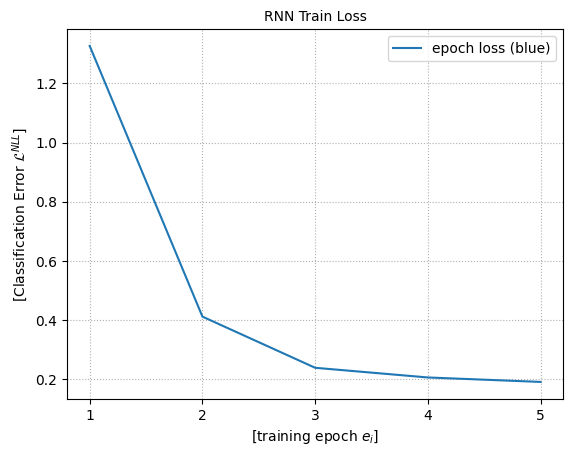

In [19]:
# Prepare plot
fig = plt.figure()
ax = fig.add_subplot(111)

# Add grid
ax.grid(linestyle='dotted')

# Plot the training epochs vs. the epochs' classification error
ax.plot(np.array(range(1, len(epoch_losses)+1)), epoch_losses, label='epoch loss (blue)')

# Plot details
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_xlabel("[training epoch $e_i$]", fontsize=10)
ax.set_ylabel(r"[Classification Error $\mathcal{L}^{NLL}$]", fontsize=10)
plt.legend(loc="upper right", numpoints=1, fancybox=True)
plt.title('RNN Train Loss', fontsize=10);

#### 3.4 Testing

In [20]:

prompt = "Saint Gallen, where the "
generate_text(model, dataset.char_to_int, dataset.int_to_char, prompt, device=device)

'Saint Gallen, where the ime debateth with decay\nL'

In [21]:
prompt = " "
generate_text(model, dataset.char_to_int, dataset.int_to_char, prompt, device=device)

' hy state,\nNot making worse what nature made so clear,\nAnd such a countard that that I have sca'

## Part 2: LSTM Time-Series Forecasting and Backtesting

In this part of the lab, we study how Long Short-Term Memory (LSTM) networks can be used to model sequential financial data. Financial time series are a natural application area for recurrent models because the next observation often depends not only on the most recent value, but also on the short-term temporal context that precedes it. Our goal is therefore to learn from a short history of daily stock returns and use that information to forecast the next return.



We will work with historical daily data of IBM stock and follow the complete prediction pipeline used in many time-series applications. First, we prepare the return series and convert it into rolling input sequences. Next, we load an LSTM model and use it to generate one-step-ahead forecasts. Finally, we interpret the predicted returns as trading signals and evaluate the resulting strategy in a backtest.



The figure below illustrates a high-level view on the machine learning process we aim to establish in this lab.



<img align='center' style='max-width: 700px' src='assets/process.png'>

Objectives:

1. Understand how daily stock prices can be transformed into returns and rolling sequences for sequence modeling.
2. Review the structure of an LSTM network used for one-step-ahead forecasting.
3. Evaluate the model on both in-sample and out-of-sample data.
4. Convert forecasts into long/short signals and compare the resulting strategy with a passive baseline.

### 1. Setup



We start by importing the libraries that will be used for data handling, modeling, visualization, and backtesting.



The next cell loads the standard scientific Python stack as well as the `bt` backtesting library. Python `bt` is a flexible backtesting framework that can be used to test quantitative trading strategies. In general, backtesting is the process of testing a strategy over a given data set (more details about the `bt` library can be found via: https://pmorissette.github.io/bt/).

In [22]:
import warnings
warnings.filterwarnings('ignore')

import importlib.util
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

def ensure_package(package_name):
    if importlib.util.find_spec(package_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name])

ensure_package('bt')
import bt

plt.rcParams['figure.figsize'] = [14, 5]
plt.rcParams['figure.dpi'] = 140

We then define the locations of the dataset and checkpoint, select the computation device, and initialize the random seeds used in this notebook.

In [23]:
DATA_PATH = './data_lstm/ibm_data_2010_2017_daily.csv'
MODEL_PATH = './models_lstm/best_lstm_model.pth'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(1234)
np.random.seed(1234)

print(f'Using device: {device}')
print(f'Data file exists: {os.path.exists(DATA_PATH)}')
print(f'Best checkpoint exists: {os.path.exists(MODEL_PATH)}')

Using device: cpu
Data file exists: True
Best checkpoint exists: True


### 2. Load the IBM Stock Series

We begin by loading the historical IBM dataset from disk. For the forecasting task in this notebook, we focus on the closing price and derive daily percentage returns from it.

The next cell reads the CSV file, cleans the columns, keeps only the original trading days, and computes the return series that will later be used by the LSTM. This avoids introducing artificial zero-return observations from weekends and holidays.

In [24]:
raw_data = pd.read_csv(DATA_PATH, sep=';', header=[0, 1], skiprows=[2], index_col=0, parse_dates=True)
stock_data = raw_data.copy()
stock_data.columns = stock_data.columns.get_level_values(0)
stock_data = stock_data.sort_index().apply(pd.to_numeric, errors='coerce')
stock_data['RETURN'] = stock_data['Close'].pct_change()
stock_data[['Close', 'RETURN']].head()

Price,Close,RETURN
2000-01-03,56.671013,NaN
2000-01-04,54.747360,-0.033944
2000-01-05,56.671013,0.035137
2000-01-06,55.693943,-0.017241
2000-01-07,55.449677,-0.004386


Four stock prices recorded each day:

- Open: first trade of the day
- High: highest price reached during the day
- Low: lowest price reached during the day
- **Close**: last trade of the day

**Daily Return**:

The percentage change in a stock's price from one day to the next:
rₜ = (pₜ - pₜ₋₁) / pₜ₋₁

For example: if IBM closed at $100 yesterday and $102 today, the return is (102 - 100) / 100 = 2%.

After preparing the dataset, we visualize the closing price and the return series. Our LSTM model will try to predict the return signal.

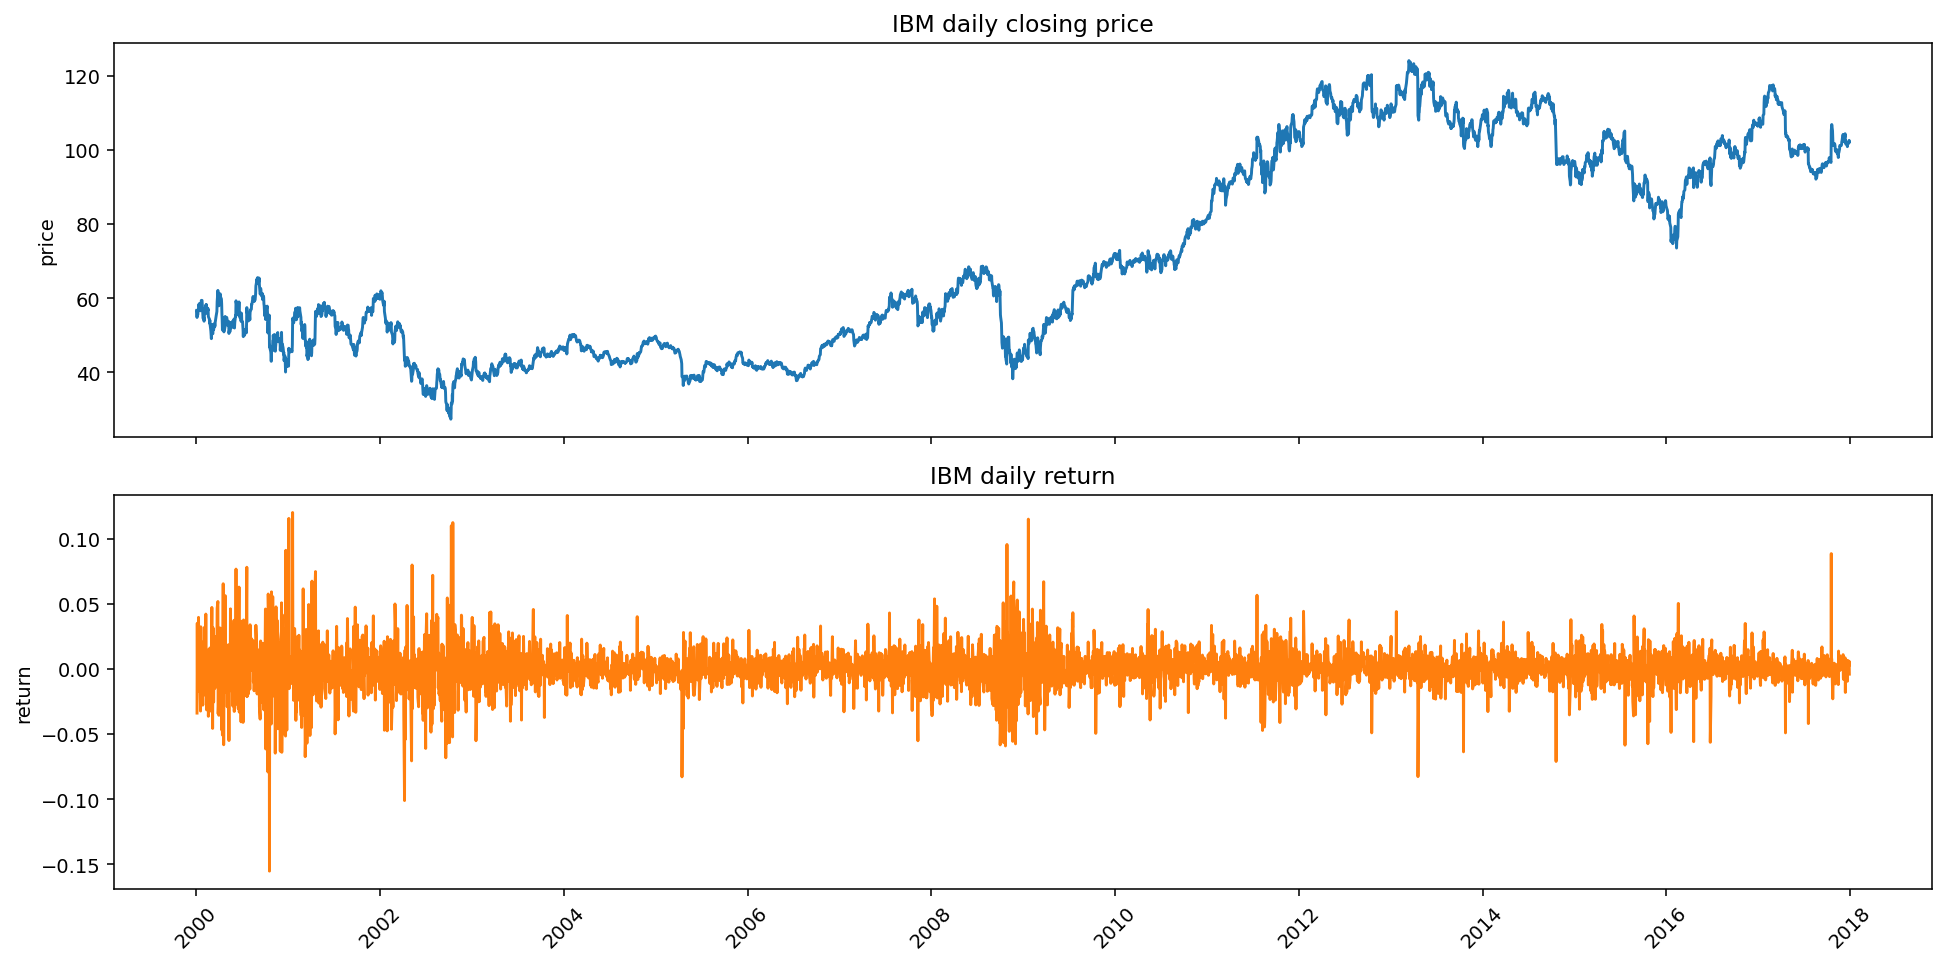

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(stock_data.index, stock_data['Close'], color='C0')
axes[0].set_title('IBM daily closing price')
axes[0].set_ylabel('price')

axes[1].plot(stock_data.index, stock_data['RETURN'], color='C1')
axes[1].set_title('IBM daily return')
axes[1].set_ylabel('return')

for tick in axes[1].get_xticklabels():
    tick.set_rotation(45)

plt.tight_layout()

### 3. Build Input Sequences



In the following, we determine the number of return time-steps $n$ each individual sequence $s^{i}$ should be comprised of. Each sequence is thereby determined by the number of predictor (return) time-steps $t$ and the prediction (return) horizon $h = t+1$.

<img align='center' style='max-width: 500px' src='assets/timesteps.png'>

In this example, we will set the number of predictor (return) time-steps to $t$=4. This indicates that the input sequence of each sample is a vector of 4 sequential daily stock returns (pls. note, the choice of $t$=4 is arbitrary and should be selected through experimentation). Furthermore, we set the predicted return horizon to 1, which specifies that we aim to forecast a single future time-step.

In [26]:
split_fraction = 0.9
time_steps, horizon = 4, 1
sequence_length = time_steps + horizon

split_row = int(len(stock_data) * split_fraction)
train_stock_data = stock_data.iloc[:split_row]
valid_stock_data = stock_data.iloc[split_row:]

print('Train rows:', len(train_stock_data))
print('Validation rows:', len(valid_stock_data))

Train rows: 4075
Validation rows: 453


Next, we extract the sequences $s^i$ of 5 time-steps. 

Thereby, we will step-wise iterate ("rolling window") over the entire sequence of daily stock returns $r_i$. In each iteration step, we extract an individual sequence of stock returns consisting of $n$ time-steps. The extracted individual sequences of daily stock returns are then collected in a single array.

<img align='center' style='max-width: 900px' src='assets/sequences.png'>

We define a helper function that extracts overlapping windows of dates and returns from a given split of the time series. Each window will later become one example for the LSTM.

In [27]:
def build_sequences(frame, sequence_length):
    # max_start is just the last safe starting index — beyond it you'd run off the end of the data and get incomplete windows.
    max_start = ((len(frame) // sequence_length) - 1) * sequence_length
    dates = frame.index.to_numpy()
    returns = frame['RETURN'].to_numpy(dtype=np.float32)
    
    date_windows = [dates[i:i + sequence_length] for i in range(1, max_start)]
    value_windows = [returns[i:i + sequence_length] for i in range(1, max_start)]
    
    return np.array(date_windows), np.array(value_windows, dtype=np.float32)

Finally, we apply the helper to both splits and convert the resulting arrays into PyTorch tensors that can be passed to the model.

In [28]:
train_dates, train_sequences = build_sequences(train_stock_data, sequence_length)
valid_dates, valid_sequences = build_sequences(valid_stock_data, sequence_length)

train_inputs = torch.from_numpy(train_sequences[:, :-1]).float()
train_targets = torch.from_numpy(train_sequences[:, 1:]).float()
valid_inputs = torch.from_numpy(valid_sequences[:, :-1]).float()
valid_targets = torch.from_numpy(valid_sequences[:, 1:]).float()

print('Train input shape:', tuple(train_inputs.shape))
print('Validation input shape:', tuple(valid_inputs.shape))

Train input shape: (4069, 4)
Validation input shape: (444, 4)


### 4. Load the Pre-Trained LSTM



The forecasting model in this notebook is an LSTM network named **'LSTMNet'** that consists of three layers in total. The first two layers correspond to LSTM cells, while the third layer corresponds to a fully-connected linear layer. 

Each LSTM layer consists of an LSTM cell with a hidden state of 51 dimensions. The third linear layer squeezes the 51 hidden state dimensions of the second LSTM cell into a single output dimension. The single output signal of the linear layer refers to the return of the next time-step predicted by the neural network. Please note, that the choice of the implemented architecture and network hyperparameters is arbitrary and should in a real-world scenario be evaluated and selected thoroughly through experimentation.

<img align='center' style='max-width: 400px' src='assets/lstmnet.png'>

In [29]:
class LSTMNet(nn.Module):
    
    def __init__(self, hidden_size=51):
        super().__init__()
        self.hidden_size = hidden_size
        
        self.lstm1 = nn.LSTMCell(1, hidden_size)
        self.lstm2 = nn.LSTMCell(hidden_size, hidden_size)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, inputs):
        predictions = []
        
        h_t1 = h_t2 = torch.zeros(inputs.size(0), self.hidden_size, dtype=torch.float32, device=inputs.device)
        c_t1 = c_t2 = torch.zeros(inputs.size(0), self.hidden_size, dtype=torch.float32, device=inputs.device)
        
        for input_t in inputs.chunk(inputs.size(1), dim=1):
            
            h_t1, c_t1 = self.lstm1(input_t, (h_t1, c_t1))
            h_t2, c_t2 = self.lstm2(h_t1, (h_t2, c_t2))
            prediction = self.linear(h_t2)
            
            predictions.append(prediction)
            
        return torch.stack(predictions, dim=1).squeeze(-1)

With the architecture in place, we can now instantiate the network, load the checkpoint parameters, switch the model to evaluation mode, and inspect its size.

In [30]:
state_dict = torch.load(MODEL_PATH, map_location=device)
lstm_model = LSTMNet().to(device)
lstm_model.load_state_dict(state_dict)
lstm_model.eval()
num_params = sum(param.numel() for param in lstm_model.parameters())
print(f'Loaded checkpoint: {MODEL_PATH}')
print(lstm_model)
print(f'Number of parameters: {num_params:,}')

Loaded checkpoint: ./models_lstm/best_lstm_model.pth
LSTMNet(
  (lstm1): LSTMCell(1, 51)
  (lstm2): LSTMCell(51, 51)
  (linear): Linear(in_features=51, out_features=1, bias=True)
)
Number of parameters: 32,284


### 5. Predict the Next Return



We first define a small helper function that extracts the final-step forecast from each input sequence and returns it together with the corresponding true target values.

In [31]:
def predict_last_step(model, inputs, targets):
    with torch.no_grad():
        predictions = model(inputs.to(device)).cpu().numpy()[:, -1]
    return predictions, targets.numpy()[:, -1]

We can now apply this helper to the in-sample and out-of-sample tensors to produce the return forecasts that will be used in the evaluation.

In [32]:
train_predictions, train_truth = predict_last_step(lstm_model, train_inputs, train_targets)
valid_predictions, valid_truth = predict_last_step(lstm_model, valid_inputs, valid_targets)

Finally, we visualize the true and predicted returns for both periods. This allows us to compare the model behavior on data from the earlier in-sample window and the later out-of-sample window.

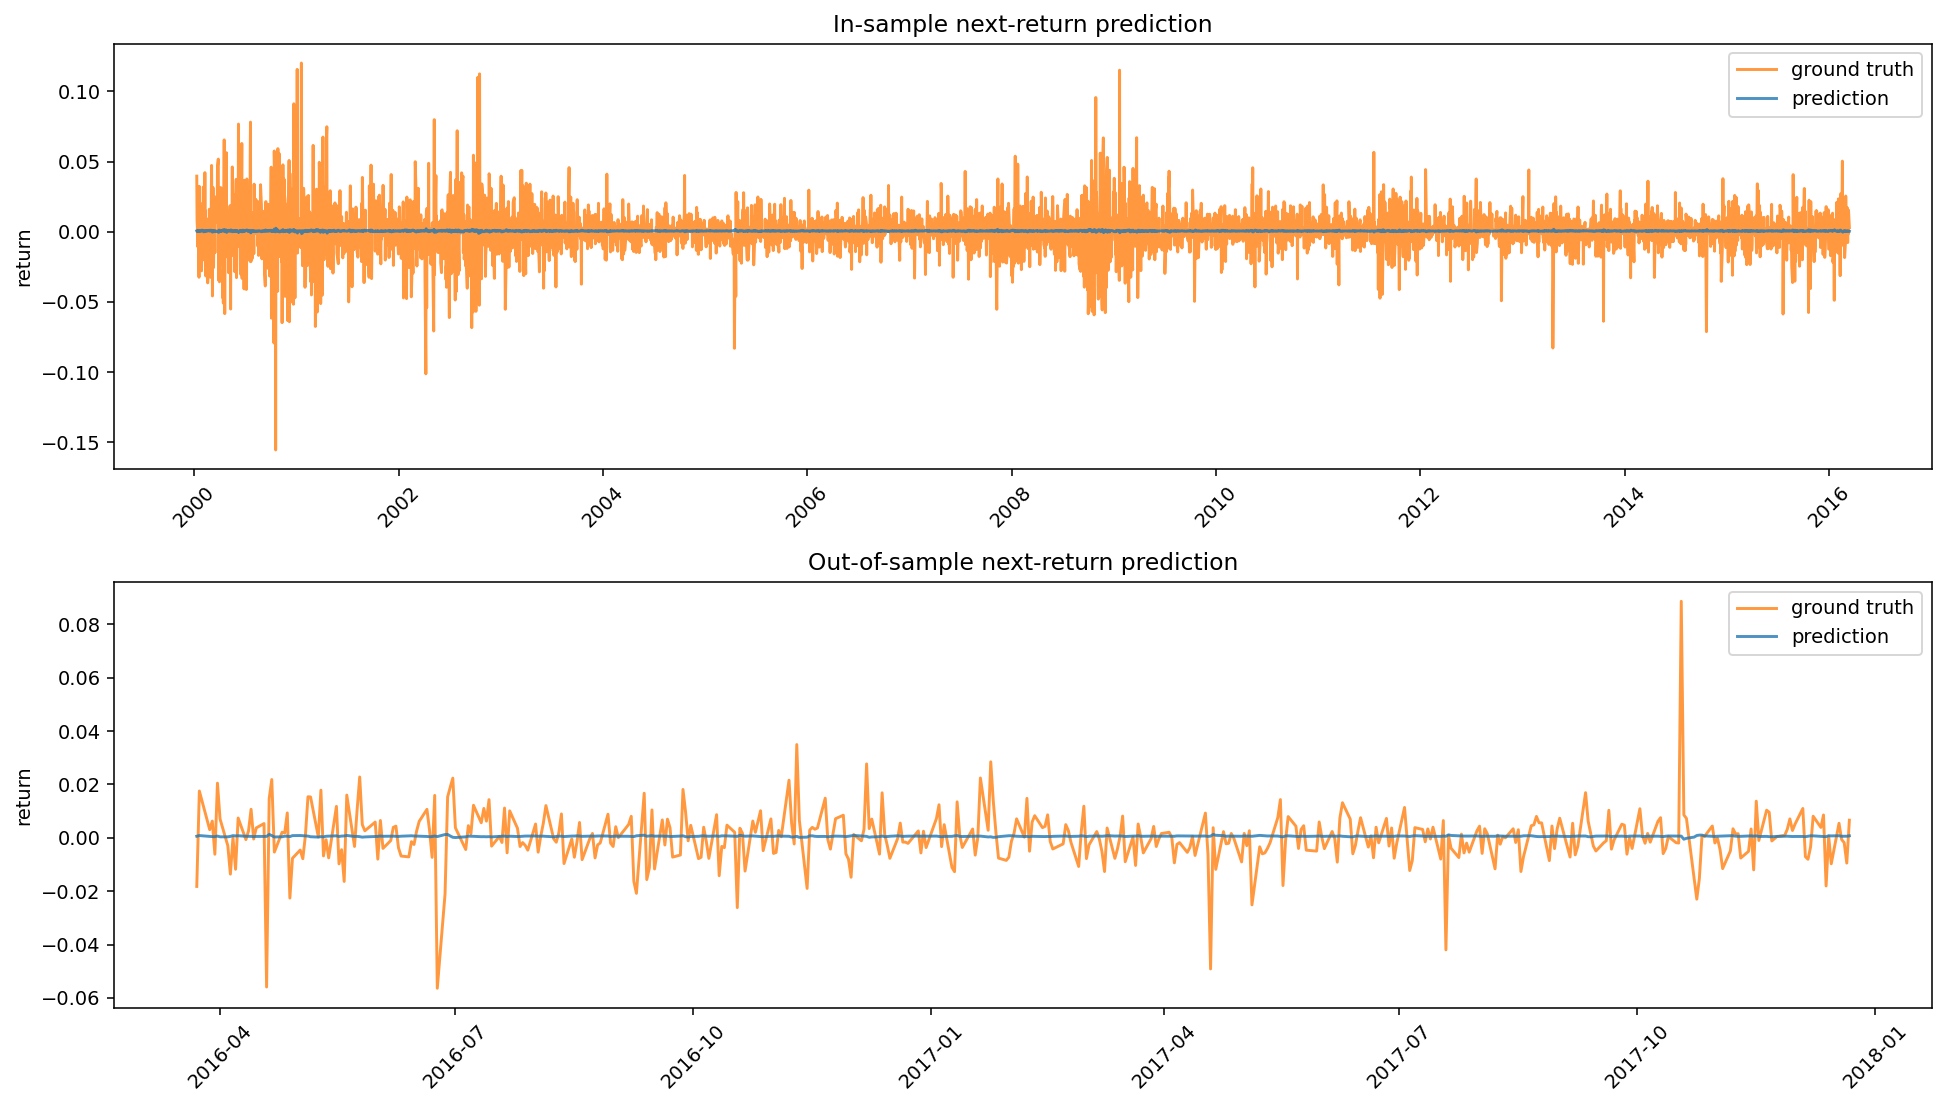

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
for ax, dates, truth, predictions, title in [
    (axes[0], train_dates[:, -1], train_truth, train_predictions, 'In-sample next-return prediction'),
    (axes[1], valid_dates[:, -1], valid_truth, valid_predictions, 'Out-of-sample next-return prediction')]:
    
    ax.plot(dates, truth, label='ground truth', color='C1', alpha=0.8)
    ax.plot(dates, predictions, label='prediction', color='C0', alpha=0.8)
    ax.set_title(title)
    ax.set_ylabel('return')
    ax.legend()
    
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)
        
plt.tight_layout()

### 6. Turn Predictions into Trading Signals

We first collect the model forecasts in a data frame aligned to the last observed trading day of each input sequence. That is the latest date at which all model inputs are known, so it is the correct decision point for the backtest.

In [34]:
signal_data = pd.DataFrame({'PREDICTION': valid_predictions, 'TARGET': valid_truth, 'PREDICTED_RETURN_DATE': pd.to_datetime(valid_dates[:, -1])}, index=pd.to_datetime(valid_dates[:, -2]))
signal_data.index.name = 'SIGNAL_DATE'
signal_data.head()

,PREDICTION,TARGET,PREDICTED_RETURN_DATE
SIGNAL_DATE,,,
2016-03-22,0.000583,-0.018231,2016-03-23
2016-03-23,0.000837,0.017538,2016-03-24
2016-03-24,0.000527,0.003042,2016-03-28
2016-03-28,0.000449,0.006267,2016-03-29
2016-03-29,0.000429,-0.006162,2016-03-30


So each row says: "on this date (index), the model predicted this return (PREDICTION) for the following date (PREDICTED_RETURN_DATE), and the actual return turned out to be (TARGET)."

We can now convert the forecast into a trading rule. A positive predicted return becomes a long signal, a negative predicted return becomes a short signal, and we remove any duplicate timestamps.
- Long (+1) — you own the stock, you profit if price goes up, you lose if price goes down
- Flat (0) — you hold cash, no exposure to the stock, price movements don't affect you
- Short (-1) — you borrowed and sold the stock, you profit if price goes down, you lose if price goes up

Notice that the LSTM strategy - for simplicity - goes either short or long, no flat.

In [35]:
signal_data['SIGNAL'] = np.where(signal_data['PREDICTION'] > 0.0, 1.0, -1.0)

# The raw stock data can have duplicate dates — the CSV may contain repeated rows for the same trading day
# due to data quality issues. When those feed into the windows, the same date can end up as the signal date for multiple windows.
signal_data = signal_data[~signal_data.index.duplicated(keep='last')]

signal_data.head()

,PREDICTION,TARGET,PREDICTED_RETURN_DATE,SIGNAL
SIGNAL_DATE,,,,
2016-03-22,0.000583,-0.018231,2016-03-23,1.0
2016-03-23,0.000837,0.017538,2016-03-24,1.0
2016-03-24,0.000527,0.003042,2016-03-28,1.0
2016-03-28,0.000449,0.006267,2016-03-29,1.0
2016-03-29,0.000429,-0.006162,2016-03-30,1.0


### 7. Backtest the LSTM Strategy



To evaluate the practical value of the model output, we backtest the generated signals over the out-of-sample period. We begin by preparing the closing-price series that will be used as the market input for both strategies.

In [36]:
# extracts the Close column and renames it to 'IBM'
stock_market_data = stock_data[['Close']].rename(columns={'Close': 'IBM'})

# trims the data to only the out-of-sample period (March 2016 → December 2017) 
stock_market_data = stock_market_data.loc[signal_data.index.min():signal_data.index.max()]

stock_market_data.head()

Price,IBM
2016-03-22,92.334785
2016-03-23,90.651428
2016-03-24,92.241249
2016-03-28,92.521843
2016-03-29,93.101685


Next, we define a small trading rule that reads the signal for the current date and translates it into a portfolio weight for IBM.

In [37]:
class SignalStrategy(bt.Algo):
    def __init__(self, signals):
        self.signals = signals

    def __call__(self, target):
        if target.now in self.signals.index:
            target.temp['weights'] = {'IBM': float(self.signals.loc[target.now])}
        return True

With the market data and trading rule in place, we can instantiate the LSTM-driven strategy, define the buy-and-hold benchmark, and execute both backtests.

In [38]:
lstm_strategy = bt.Strategy('lstm',[bt.algos.SelectAll(), SignalStrategy(signal_data['SIGNAL']), bt.algos.Rebalance()])

base_signals = signal_data['SIGNAL'].copy()
base_signals[:] = 1.0
base_strategy = bt.Strategy('buy_and_hold',[bt.algos.SelectAll(), SignalStrategy(base_signals), bt.algos.Rebalance()])

backtest_lstm = bt.Backtest(lstm_strategy, stock_market_data)

backtest_base = bt.Backtest(base_strategy, stock_market_data)

backtest_results = bt.run(backtest_lstm, backtest_base)
backtest_results.display()

Stat                 lstm        buy_and_hold
-------------------  ----------  --------------
Start                2016-03-21  2016-03-21
End                  2017-12-21  2017-12-21
Risk-free rate       0.00%       0.00%

Total Return         5.79%       9.20%
Daily Sharpe         0.28        0.38
Daily Sortino        0.40        0.55
CAGR                 3.26%       5.15%
Max Drawdown         -21.65%     -21.65%
Calmar Ratio         0.15        0.24

MTD                  -1.60%      -1.60%
3m                   2.05%       5.34%
6m                   -2.59%      0.55%
YTD                  -8.15%      -5.19%
1Y                   -8.89%      -5.95%
3Y (ann.)            -           -
5Y (ann.)            -           -
10Y (ann.)           -           -
Since Incep. (ann.)  3.26%       5.15%

Daily Sharpe         0.28        0.38
Daily Sortino        0.40        0.55
Daily Mean (ann.)    4.56%       6.36%
Daily Vol (ann.)     16.59%      16.59%
Daily Skew           0.44        0.42
Daily Ku

After running both strategies, we inspect the aggregated performance table and then focus on the relative equity curves of the LSTM strategy and the passive benchmark.

The next cell visualizes how both portfolios evolved over time and also reports the buy-and-hold return over the same evaluation window.

Buy-and-hold return over the evaluation window: 9.20%


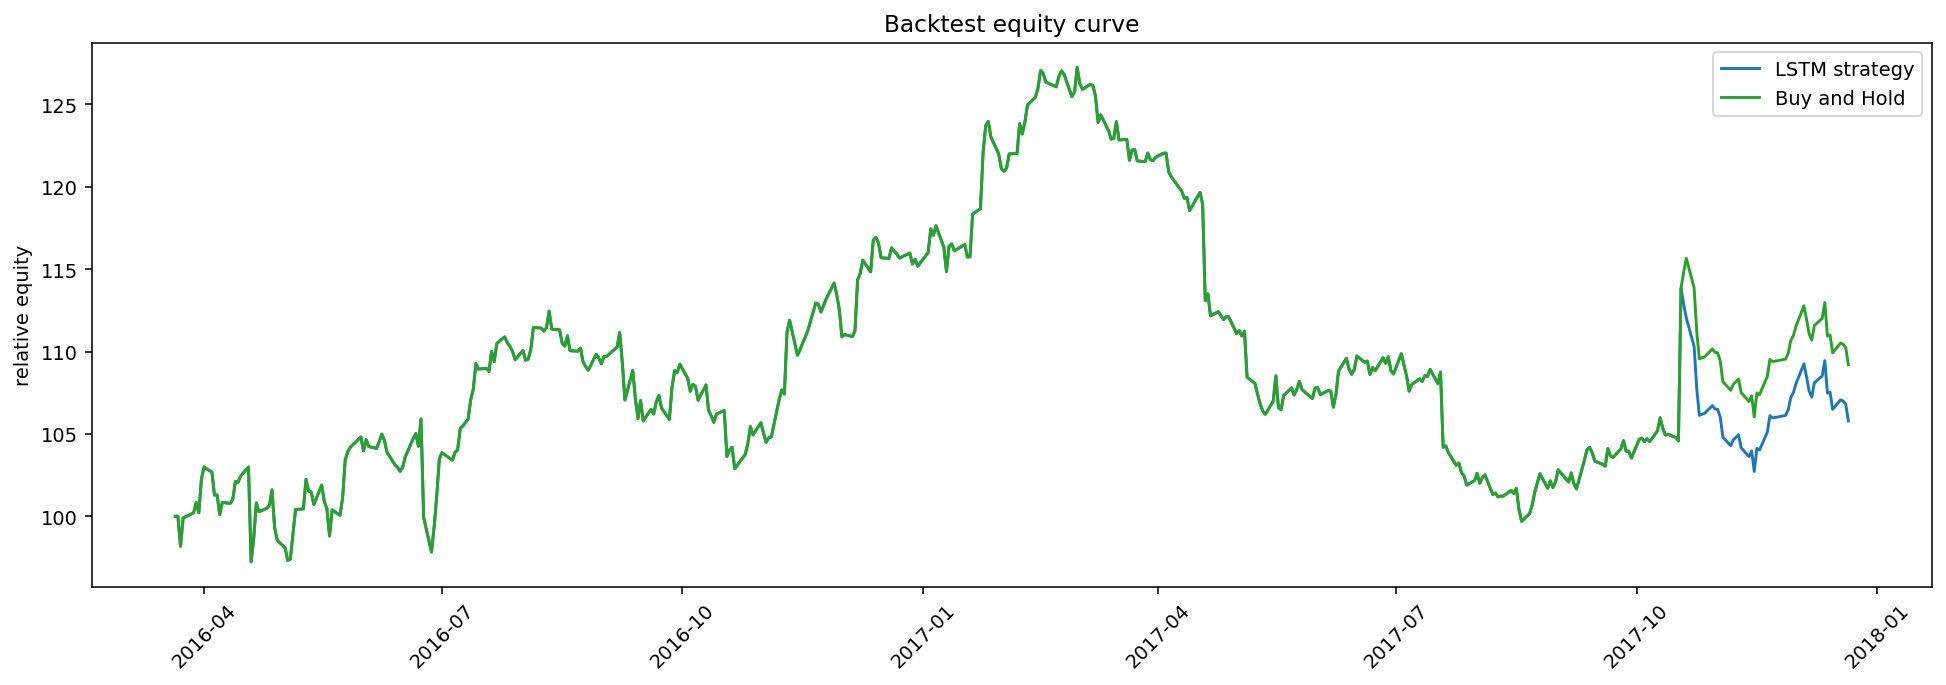

In [39]:
lstm_equity = backtest_lstm.strategy.prices.to_frame(name='LSTM strategy')
base_equity = backtest_base.strategy.prices.to_frame(name='Buy and Hold')
buy_hold_return = (stock_market_data['IBM'].iloc[-1] - stock_market_data['IBM'].iloc[0]) / stock_market_data['IBM'].iloc[0]

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
for label, frame, color in [('LSTM strategy', lstm_equity, 'C0'), ('Buy and Hold', base_equity, 'C2')]:
    ax.plot(frame.index, frame.iloc[:, 0], label=label, color=color)

ax.set(title='Backtest equity curve', ylabel='relative equity')
ax.legend()
for tick in ax.get_xticklabels():
    tick.set_rotation(45)

plt.tight_layout()
print(f'Buy-and-hold return over the evaluation window: {buy_hold_return:.2%}')

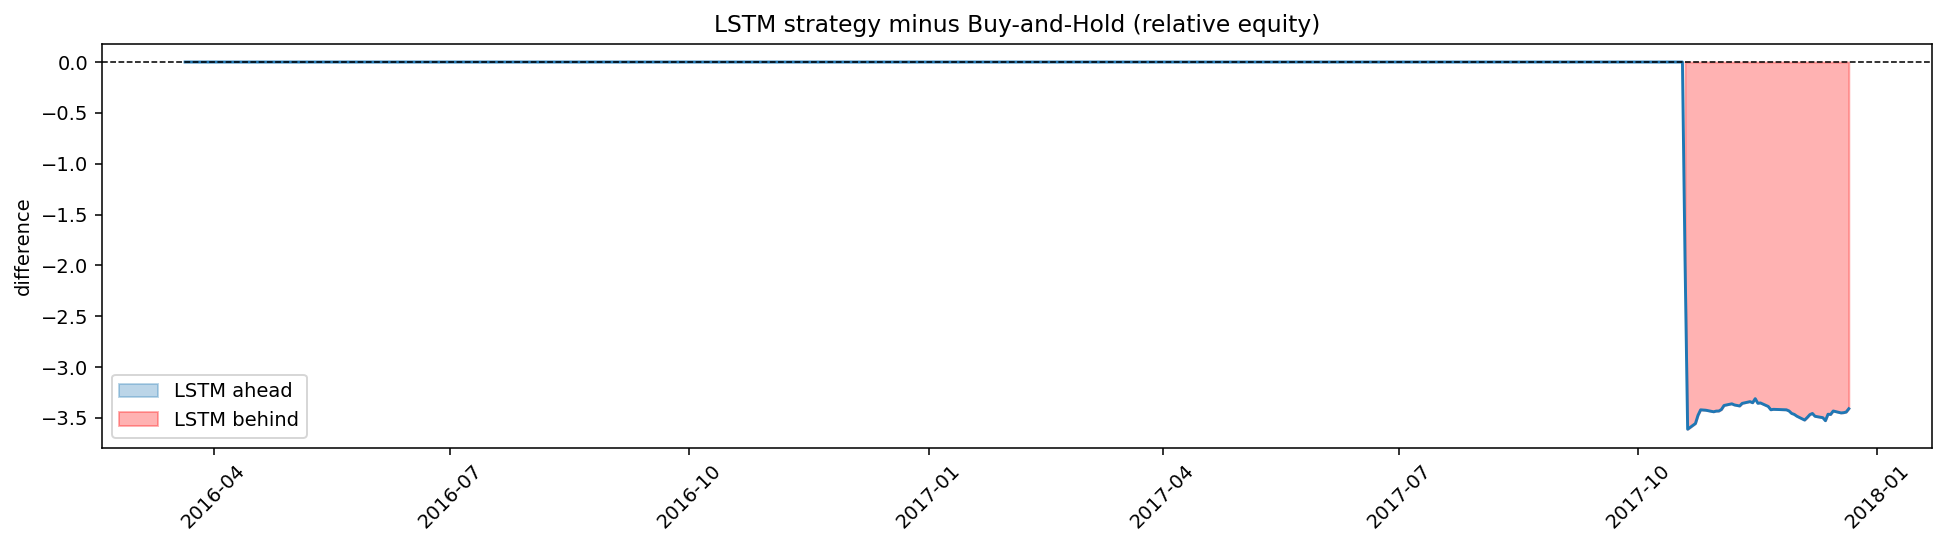

In [40]:
# Plot the difference between LSTM and buy-and-hold equity curves
diff = lstm_equity.iloc[:, 0] - base_equity.iloc[:, 0]

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.plot(diff.index, diff.values, color='C0')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.fill_between(diff.index, diff.values, 0, where=diff.values >= 0, color='C0', alpha=0.3, label='LSTM ahead')
ax.fill_between(diff.index, diff.values, 0, where=diff.values < 0, color='red', alpha=0.3, label='LSTM behind')
ax.set(title='LSTM strategy minus Buy-and-Hold (relative equity)', ylabel='difference')
ax.legend()
for tick in ax.get_xticklabels():
    tick.set_rotation(45)
plt.tight_layout()

- Blue fill — periods where LSTM is ahead
- Red fill — periods where LSTM is behind
- Dashed line at 0 — the breakeven point

Keep in mind:
If the LSTM predicted a positive return every day, its signals would all be +1 and its equity curve would be identical to buy-and-hold.